**Part 1: Data Preparation and Exploration**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Load the dataset
df = pd.read_csv('exchange_rate.csv', parse_dates=['date'], index_col='date')

In [ ]:
df.head()

,Ex_rate
date,
01-01-1990 00:00,0.7855
02-01-1990 00:00,0.7818
03-01-1990 00:00,0.7867
04-01-1990 00:00,0.7860
05-01-1990 00:00,0.7849


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7588 entries, 01-01-1990 00:00 to 10-10-2010 00:00
Data columns (total 1 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Ex_rate  7588 non-null   float64
dtypes: float64(1)
memory usage: 118.6+ KB


In [ ]:
df.describe()

,Ex_rate
count,7588.000000
mean,0.776974
std,0.136620
min,0.483297
25%,0.701422
50%,0.761377
75%,0.873477
max,1.102536


In [ ]:
#checking null values
df.isnull().sum()

,0
Ex_rate,0


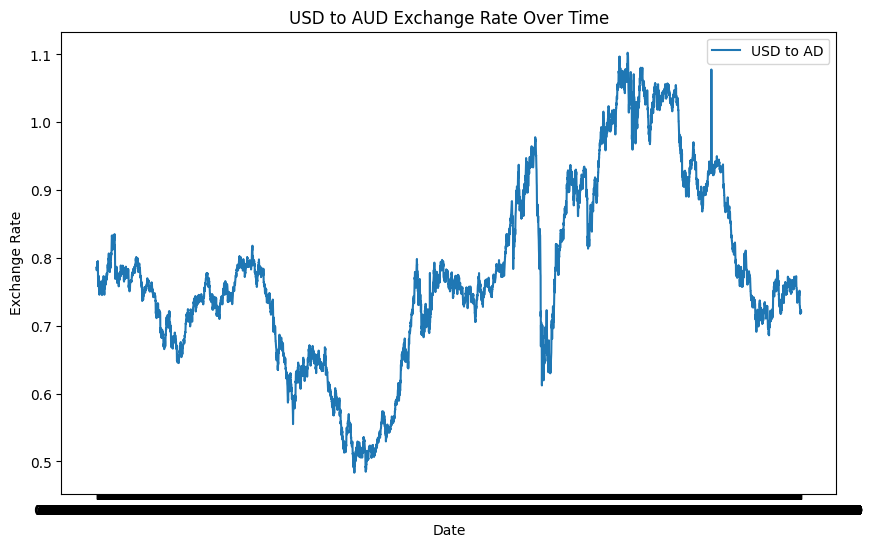

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(df['Ex_rate'], label='USD to AD')
plt.title('USD to AUD Exchange Rate Over Time')
plt.xlabel('Date')
plt.ylabel('Exchange Rate')
plt.legend()
plt.show()

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose

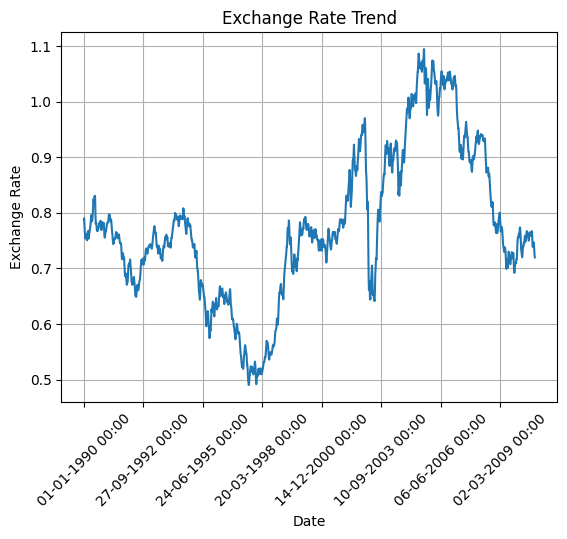

In [ ]:
result=seasonal_decompose(df['Ex_rate'], model='additive', period=10)
result.trend.plot() #for trend
plt.title('Exchange Rate Trend')
plt.xlabel('Date')
plt.ylabel('Exchange Rate')
plt.grid(True)
plt.xticks(rotation=45)
plt.show()

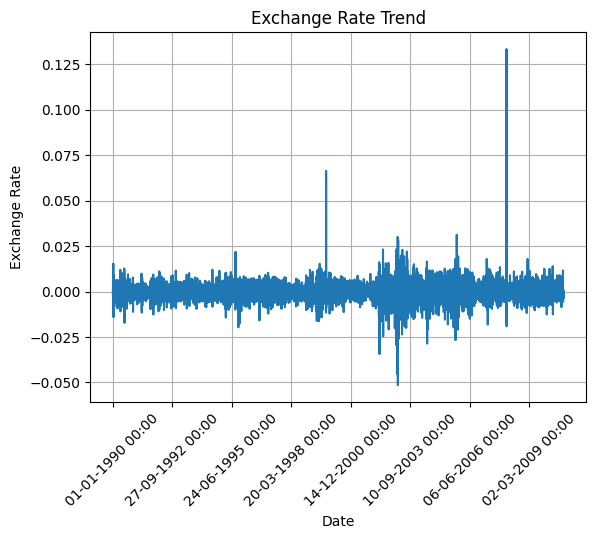

In [ ]:
result.resid.plot() #for residual
plt.title('Exchange Rate Trend')
plt.xlabel('Date')
plt.ylabel('Exchange Rate')
plt.grid(True)
plt.xticks(rotation=45)
plt.show()

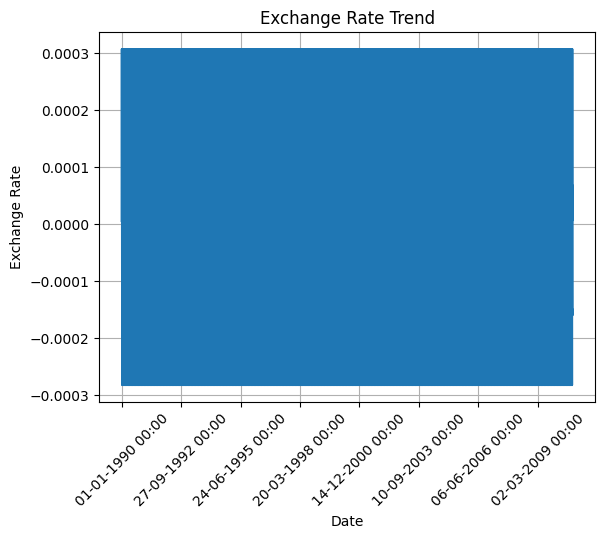

In [ ]:
result.seasonal.plot() #for seasional
plt.title('Exchange Rate Trend')
plt.xlabel('Date')
plt.ylabel('Exchange Rate')
plt.grid(True)
plt.xticks(rotation=45)
plt.show()

**Part 2: Model Building - ARIMA**

In [ ]:
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
import statsmodels.api as smt

In [ ]:
# Stationarity Test Function
def test_stationarity(timeseries):
    # Rolling statistics
    rollmean = timeseries.rolling(window=30).mean()
    rollstd = timeseries.rolling(window=30).std()
    # Plot rolling statistics
    plt.figure(figsize=(10,5))
    plt.plot(timeseries, color='red', label='Original')
    plt.plot(rollmean, color='green', label='Rolling Mean')
    plt.plot(rollstd, color='blue', label='Rolling Std')
    plt.legend(loc='best')
    plt.title('Rolling Mean & Standard Deviation')
    plt.grid(True)
    plt.show()
    # Dickey-Fuller Test
    print('Results of Dickey-Fuller Test:\n')
    df_test = adfuller(timeseries.dropna())

    output = pd.Series(df_test[0:4],index=['Test Statistic','p-value','#Lags Used','Number of Observations Used'])
    for key, value in df_test[4].items():
        output['Critical Value (%s)' % key] = value
    print(output)

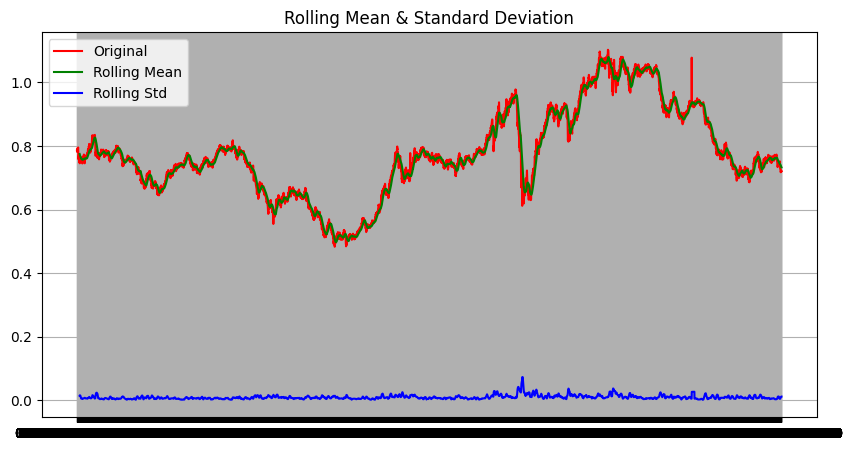

Results of Dickey-Fuller Test:

Test Statistic                   -1.664994
p-value                           0.449233
#Lags Used                        1.000000
Number of Observations Used    7586.000000
Critical Value (1%)              -3.431212
Critical Value (5%)              -2.861921
Critical Value (10%)             -2.566973
dtype: float64


In [ ]:
# Check Original Series
test_stationarity(df['Ex_rate'])

In [ ]:
# Make Data Stationary using Differencing
df['Ex_diff'] = df['Ex_rate'] - df['Ex_rate'].shift(1)

In [ ]:
# Remove NaN values
df.dropna(inplace=True)

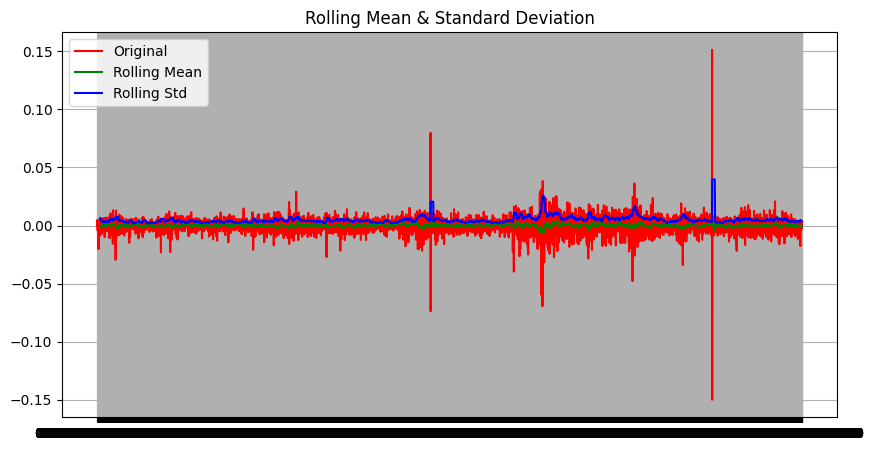

Results of Dickey-Fuller Test:

Test Statistic                  -99.393431
p-value                           0.000000
#Lags Used                        0.000000
Number of Observations Used    7586.000000
Critical Value (1%)              -3.431212
Critical Value (5%)              -2.861921
Critical Value (10%)             -2.566973
dtype: float64


In [ ]:
# Check stationarity again
test_stationarity(df['Ex_diff'])

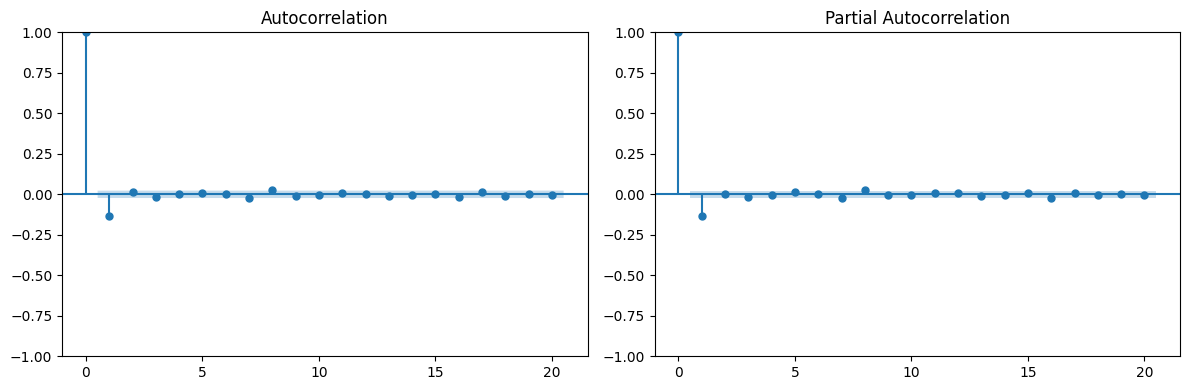

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(1, 2, figsize=(12,4))
# ACF Plot
plot_acf(df['Ex_diff'],lags=20,ax=axes[0])
# PACF Plot
plot_pacf(df['Ex_diff'],lags=20,ax=axes[1])
plt.tight_layout()
plt.show()

In [ ]:
model = ARIMA(df['Ex_rate'],order=(2,1,1))

# Fit model
result = model.fit()
# Model Summary
print(result.summary())

                               SARIMAX Results                                
Dep. Variable:                Ex_rate   No. Observations:                 7587
Model:                 ARIMA(2, 1, 1)   Log Likelihood               28050.090
Date:                Fri, 15 May 2026   AIC                         -56092.180
Time:                        13:48:27   BIC                         -56064.444
Sample:                             0   HQIC                        -56082.661
                               - 7587                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0654      0.001    -60.678      0.000      -0.068      -0.063
ar.L2          0.0084      0.006      1.415      0.157      -0.003       0.020
ma.L1         -0.0661      0.001    -59.597      0.0

In [ ]:
# Predictions
arima_predictions = result.predict()
arima_predictions

,predicted_mean
date,
02-01-1990 00:00,0.000000
03-01-1990 00:00,0.781800
04-01-1990 00:00,0.786056
05-01-1990 00:00,0.786090
06-01-1990 00:00,0.785045
...,...
06-10-2010 00:00,0.718837
07-10-2010 00:00,0.718522
08-10-2010 00:00,0.721399


In [ ]:
# Forecast Future Values
arima_forecast = result.forecast(30)
arima_forecast

,predicted_mean
7587,0.720826
7588,0.720826
7589,0.720826
7590,0.720826
7591,0.720826
7592,0.720826
7593,0.720826
7594,0.720826
7595,0.720826
7596,0.720826


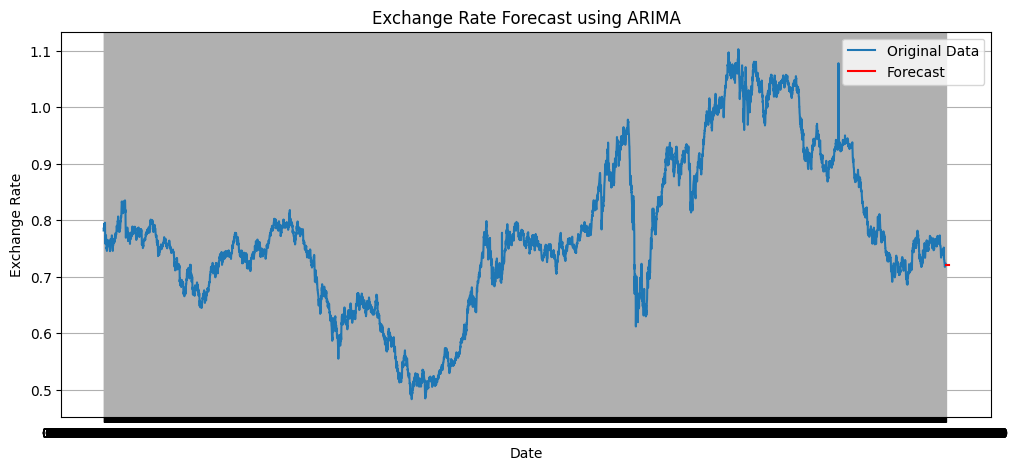

In [ ]:
# Plot Forecast
plt.figure(figsize=(12,5))
plt.plot(df['Ex_rate'], label='Original Data')
plt.plot(arima_forecast, label='Forecast', color='red')
#plt.plot(arima_predictions, label='Predicted Data',color='green')
plt.title('Exchange Rate Forecast using ARIMA')
plt.xlabel('Date')
plt.ylabel('Exchange Rate')
plt.legend()
plt.grid(True)
plt.show()

**Part 2: Model Building -EXPONENTIAL SMOOTHING**

In [ ]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing
exp_model = ExponentialSmoothing(df['Ex_rate'],trend='add',seasonal=None)
# Fit model
exp_result = exp_model.fit()
# Predicted values
# Predict existing values
exp_predictions = exp_result.predict(start=0,end=len(df)-1)
# Forecast future values
exp_forecast = exp_result.forecast(30)


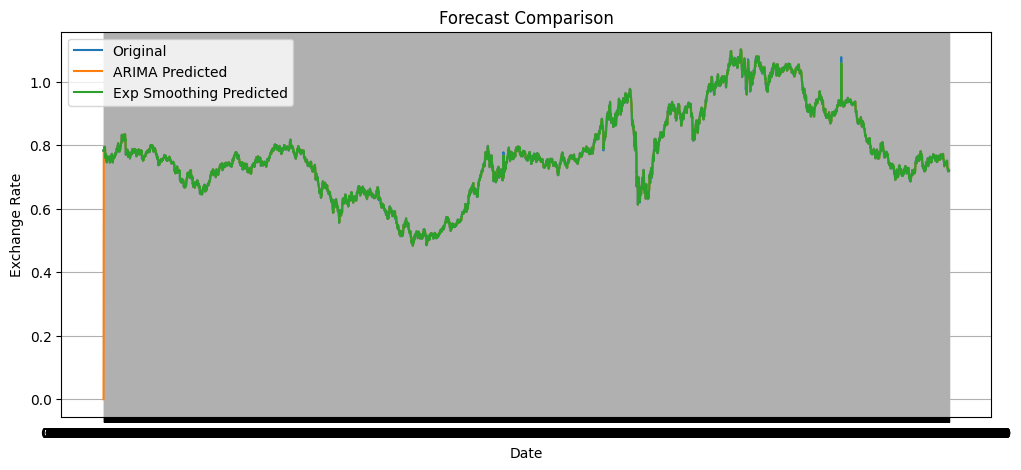

In [ ]:
# VISUALIZATION
plt.figure(figsize=(12,5))
plt.plot(df['Ex_rate'], label='Original')
plt.plot(arima_predictions, label='ARIMA Predicted')
plt.plot(exp_predictions, label='Exp Smoothing Predicted')
plt.title('Forecast Comparison')
plt.xlabel('Date')
plt.ylabel('Exchange Rate')
plt.legend()
plt.grid(True)
plt.show()


**Part 3: Evaluation and Comparison**

In [ ]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,mean_absolute_percentage_error

In [ ]:
# ERROR METRICS - ARIMA
arima_mae = mean_absolute_error(df['Ex_rate'],arima_predictions)
arima_rmse = np.sqrt(mean_squared_error(df['Ex_rate'],arima_predictions))
arima_mape = mean_absolute_percentage_error(df['Ex_rate'],arima_predictions) * 100

In [ ]:
# ERROR METRICS - EXPONENTIAL SMOOTHING
exp_mae = mean_absolute_error(df['Ex_rate'],exp_predictions)
exp_rmse = np.sqrt(mean_squared_error(df['Ex_rate'],exp_predictions))
exp_mape = mean_absolute_percentage_error(df['Ex_rate'],exp_predictions) * 100

In [ ]:
# RESULTS TABLE
results = pd.DataFrame({
    'Model': ['ARIMA','Exponential Smoothing'],

    'MAE': [arima_mae,exp_mae],

    'RMSE': [arima_rmse,exp_rmse],

    'MAPE': [arima_mape,exp_mape]})
print(results)


                   Model       MAE      RMSE      MAPE
0                  ARIMA  0.003795  0.010794  0.495151
1  Exponential Smoothing  0.003693  0.005997  0.481958


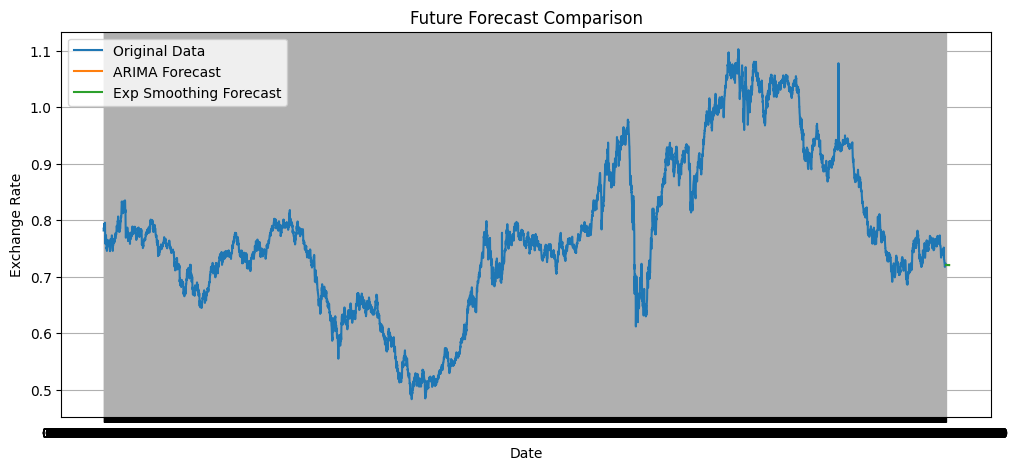

In [85]:
# FUTURE FORECAST VISUALIZATION
plt.figure(figsize=(12,5))
plt.plot(df['Ex_rate'], label='Original Data')
plt.plot(arima_forecast, label='ARIMA Forecast')
plt.plot(exp_forecast, label='Exp Smoothing Forecast')
plt.title('Future Forecast Comparison')
plt.xlabel('Date')
plt.ylabel('Exchange Rate')
plt.legend()
plt.grid(True)
plt.show()

**ARIMA Model:**

ARIMA performed well in capturing temporal patterns and fluctuations in exchange rates.

It is effective for non-stationary time series after applying differencing.
The model uses past observations and error terms for forecasting.

ARIMA generally provides better accuracy when the data contains strong time dependencies.

A limitation of ARIMA is that selecting appropriate (p, d, q) parameters can be complex and time-consuming.

**Exponential Smoothing Model:**

Exponential Smoothing is simple and computationally efficient.

It performs well for data with consistent trends and smooth variations.

The model gives higher importance to recent observations.

It is easier to implement compared to ARIMA.

However, it may not capture complex temporal relationships and sudden fluctuations effectively.

**Error Metrics Comparison:**

MAE measures the average prediction error.

RMSE penalizes larger forecasting errors more heavily.

MAPE shows prediction error in percentage form.

The model with lower MAE, RMSE, and MAPE values is considered better for forecasting accuracy.

**Conclusion:**

Both ARIMA and Exponential Smoothing models were successfully applied to forecast exchange rates.

ARIMA captured time-dependent patterns more effectively and generally produced more accurate forecasts.

Exponential Smoothing provided stable predictions with simpler implementation.

Based on the observed error metrics, the model with the lowest MAE, RMSE, and MAPE achieved the best forecasting performance.

Overall, ARIMA is more suitable for complex exchange rate forecasting, while Exponential Smoothing is useful for simpler trend-based forecasting tasks.